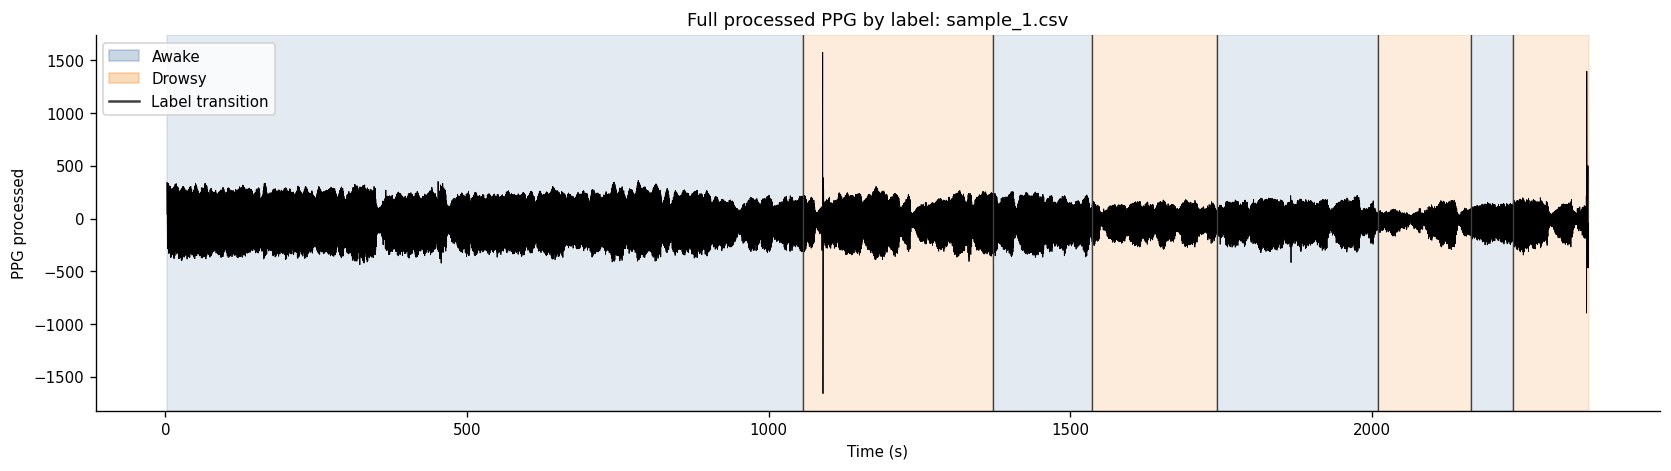

Session: sample_1.csv | Samples: 117,828 | fs: 50.000 Hz | Label segments: 8


In [1]:
# Cell 1: Load and visualize one complete processed session
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def find_project_root(start: Path) -> Path:
    """Find the phase1 project root."""
    for candidate in (start, *start.parents):
        if (candidate / "src" / "segmentation").is_dir():
            return candidate
        phase1_dir = candidate / "phase1"
        if (phase1_dir / "src" / "segmentation").is_dir():
            return phase1_dir
    raise FileNotFoundError("Cannot locate the phase1 project root")


def estimate_sampling_rate(values: np.ndarray) -> float:
    """Estimate sampling rate from positive time intervals."""
    intervals = np.diff(values)
    valid = intervals[np.isfinite(intervals) & (intervals > 0)]
    if valid.size == 0:
        raise ValueError("Time axis has no positive finite interval")
    return float(1.0 / np.median(valid))


def contiguous_runs(values: np.ndarray) -> list[tuple[int, int, object]]:
    """Return start, exclusive end, and value for each run."""
    values = np.asarray(values)
    if values.size == 0:
        return []
    changes = np.flatnonzero(values[1:] != values[:-1]) + 1
    starts = np.concatenate(([0], changes))
    ends = np.concatenate((changes, [len(values)]))
    return [(start, end, values[start]) for start, end in zip(starts, ends)]


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

SESSION_NAME = "sample_1.csv"
DATA_PATH = PROJECT_ROOT / "data_processed" / "dhdata" / SESSION_NAME
LABEL_NAMES = {0: "Awake", 1: "Drowsy"}
LABEL_COLORS = {0: "#4C78A8", 1: "#F58518"}
GAP_FACTOR = 1.5

session_frame = pd.read_csv(DATA_PATH)
required_columns = {"Time (s)", "PPG processed", "Label"}
missing_columns = required_columns.difference(session_frame.columns)
if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")

time_s = pd.to_numeric(
    session_frame["Time (s)"], errors="raise"
).to_numpy(dtype=float)
ppg_processed = pd.to_numeric(
    session_frame["PPG processed"], errors="raise"
).to_numpy(dtype=float)
labels = pd.to_numeric(
    session_frame["Label"], errors="raise"
).to_numpy(dtype=int)
fs = estimate_sampling_rate(time_s)

label_segments = [
    {
        "segment_id": index,
        "start": start,
        "end": end,
        "label": int(label),
    }
    for index, (start, end, label) in enumerate(
        contiguous_runs(labels), start=1
    )
]

mpl.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "figure.dpi": 120,
    "font.size": 9,
})
fig, axis = plt.subplots(figsize=(14, 4))
axis.plot(time_s, ppg_processed, color="black", linewidth=0.5)
for segment in label_segments:
    start = segment["start"]
    end = segment["end"]
    axis.axvspan(
        time_s[start],
        time_s[end - 1] + 1.0 / fs,
        color=LABEL_COLORS[segment["label"]],
        alpha=0.15,
    )
for transition in np.flatnonzero(labels[1:] != labels[:-1]) + 1:
    axis.axvline(time_s[transition], color="0.25", linewidth=0.8)
axis.set(
    title=f"Full processed PPG by label: {SESSION_NAME}",
    xlabel="Time (s)",
    ylabel="PPG processed",
)
axis.legend(handles=[
    Patch(color=LABEL_COLORS[0], alpha=0.3, label="Awake"),
    Patch(color=LABEL_COLORS[1], alpha=0.3, label="Drowsy"),
    Line2D([0], [0], color="0.25", label="Label transition"),
])
fig.tight_layout()
plt.show()
print(
    f"Session: {SESSION_NAME} | Samples: {len(time_s):,} | "
    f"fs: {fs:.3f} Hz | Label segments: {len(label_segments)}"
)

In [2]:
# Cell 2: Load raw PPG and SQI, then run the segmentation core
from segmentation.segmentation import segment_session  # noqa: E402


def parse_sqi(values: pd.Series) -> np.ndarray:
    """Parse a boolean SQI artifact mask."""
    if pd.api.types.is_bool_dtype(values):
        return values.to_numpy(dtype=bool)
    if pd.api.types.is_numeric_dtype(values):
        return values.to_numpy(dtype=float) != 0
    normalized = values.astype(str).str.strip().str.lower()
    mapping = {"true": True, "false": False, "1": True, "0": False}
    invalid = normalized[~normalized.isin(mapping)]
    if not invalid.empty:
        raise ValueError(f"Invalid SQI values: {invalid.unique().tolist()}")
    return normalized.map(mapping).to_numpy(dtype=bool)


def build_candidates(
    label_values: np.ndarray,
    sample_rate: float,
    window_sizes: tuple[int, ...],
) -> list[dict]:
    """Build the core's full, label-local candidate grid."""
    candidates = []
    for segment_id, (start, end, label) in enumerate(
        contiguous_runs(label_values), start=1
    ):
        for window_s in window_sizes:
            samples = int(round(window_s * sample_rate))
            for index in range((end - start) // samples):
                window_start = start + index * samples
                candidates.append({
                    "segment_id": segment_id,
                    "window_s": window_s,
                    "start": window_start,
                    "end": window_start + samples,
                    "label": int(label),
                })
    return candidates


required_columns = {"IR Value raw", "SQI"}
missing_columns = required_columns.difference(session_frame.columns)
if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")

ppg_raw = pd.to_numeric(
    session_frame["IR Value raw"], errors="raise"
).to_numpy(dtype=float)
sqi_mask = parse_sqi(session_frame["SQI"])
WINDOW_SIZES = (60, 120, 180, 240, 300)

segmentation_results = segment_session(
    time_s=time_s,
    ppg_raw=ppg_raw,
    ppg_processed=ppg_processed,
    labels=labels,
    sqi_mask=sqi_mask,
    fs=fs,
    session_id=SESSION_NAME,
    window_sizes=WINDOW_SIZES,
    gap_factor=GAP_FACTOR,
)

if set(segmentation_results) != set(WINDOW_SIZES):
    raise AssertionError("Segmentation output has incorrect keys")
if not all(isinstance(value, list) for value in segmentation_results.values()):
    raise AssertionError("Every segmentation output value must be a list")

short_end = min(len(time_s), int(round(10 * fs)))
empty_result = segment_session(
    time_s[:short_end],
    ppg_raw[:short_end],
    ppg_processed[:short_end],
    labels[:short_end],
    sqi_mask[:short_end],
    fs,
    session_id=SESSION_NAME,
    window_sizes=WINDOW_SIZES,
    gap_factor=GAP_FACTOR,
)
empty_key_contract = (
    set(empty_result) == set(WINDOW_SIZES)
    and all(value == [] for value in empty_result.values())
)
if not empty_key_contract:
    raise AssertionError("Empty output lists were not preserved")

candidate_windows = build_candidates(labels, fs, WINDOW_SIZES)
core_output = pd.DataFrame({
    "Window (s)": WINDOW_SIZES,
    "Valid windows": [
        len(segmentation_results[size]) for size in WINDOW_SIZES
    ],
    "Key present": [size in segmentation_results for size in WINDOW_SIZES],
    "List output": [
        isinstance(segmentation_results[size], list)
        for size in WINDOW_SIZES
    ],
})
display(core_output.style.hide(axis="index"))
print(f"Empty-list output contract passed: {empty_key_contract}")

Window (s),Valid windows,Key present,List output
60,34,True,True
120,14,True,True
180,7,True,True
240,5,True,True
300,3,True,True


Empty-list output contract passed: True


In [3]:
# Cell 3: Summarize retained windows by duration and label
window_count_rows = []
for window_s in WINDOW_SIZES:
    windows = segmentation_results[window_s]
    awake_count = sum(window["label"] == 0 for window in windows)
    drowsy_count = sum(window["label"] == 1 for window in windows)
    window_count_rows.append({
        "Window (s)": window_s,
        "Awake": awake_count,
        "Drowsy": drowsy_count,
        "Total": len(windows),
    })

window_count_summary = pd.DataFrame(window_count_rows)
display(window_count_summary.style.hide(axis="index"))

Window (s),Awake,Drowsy,Total
60,24,10,34
120,11,3,14
180,6,1,7
240,5,0,5
300,3,0,3


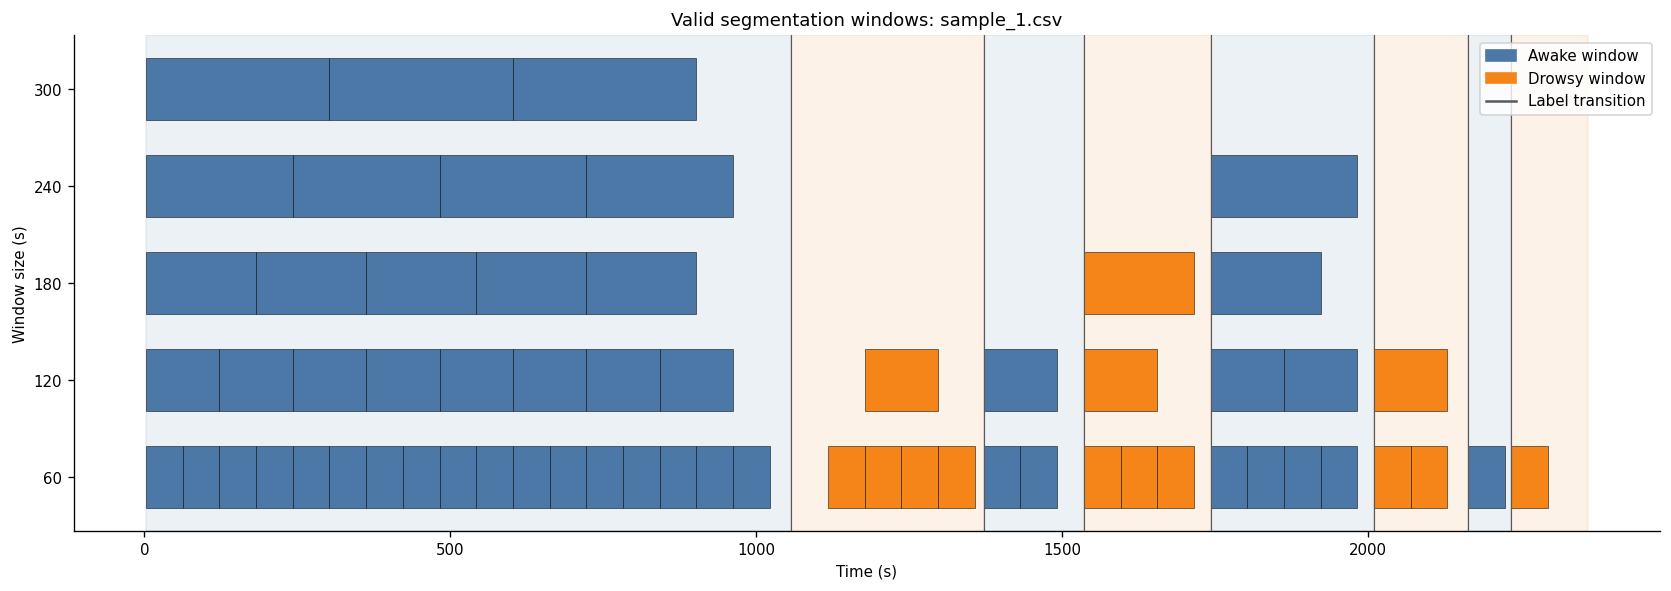

In [4]:
# Cell 4: Plot the full-session window timeline
fig, axis = plt.subplots(figsize=(14, 5))
for segment in label_segments:
    axis.axvspan(
        time_s[segment["start"]],
        time_s[segment["end"] - 1] + 1.0 / fs,
        color=LABEL_COLORS[segment["label"]],
        alpha=0.10,
    )

for row, window_s in enumerate(WINDOW_SIZES):
    for window in segmentation_results[window_s]:
        width = window["end_time"] - window["start_time"] + 1.0 / fs
        axis.broken_barh(
            [(window["start_time"], width)],
            (row - 0.32, 0.64),
            facecolors=LABEL_COLORS[window["label"]],
            edgecolors="black",
            linewidth=0.3,
        )

for transition in np.flatnonzero(labels[1:] != labels[:-1]) + 1:
    axis.axvline(time_s[transition], color="0.35", linewidth=0.7)
axis.set(
    title=f"Valid segmentation windows: {SESSION_NAME}",
    xlabel="Time (s)",
    ylabel="Window size (s)",
    yticks=range(len(WINDOW_SIZES)),
    yticklabels=WINDOW_SIZES,
)
axis.legend(handles=[
    Patch(color=LABEL_COLORS[0], label="Awake window"),
    Patch(color=LABEL_COLORS[1], label="Drowsy window"),
    Line2D([0], [0], color="0.35", label="Label transition"),
])
fig.tight_layout()
plt.show()

In [5]:
# Cell 5: Check the integrity of every retained window
def source_indices(window: dict, source_time: np.ndarray) -> tuple[int, int]:
    """Locate a retained window in the source session."""
    start = int(np.searchsorted(source_time, window["start_time"]))
    end = start + len(window["time"])
    if start >= len(source_time) or not np.isclose(
        source_time[start], window["start_time"]
    ):
        raise AssertionError("Window start time is absent from the source")
    return start, end


check_names = [
    "Equal array lengths",
    "Expected sample count",
    "Single label",
    "No SQI-invalid sample",
    "No acquisition gap",
    "Raw/processed same interval",
]
integrity_rows = []
for window_s in WINDOW_SIZES:
    expected_samples = int(round(window_s * fs))
    for window in segmentation_results[window_s]:
        start, end = source_indices(window, time_s)
        lengths = [
            len(window["time"]),
            len(window["ppg_raw"]),
            len(window["ppg_processed"]),
        ]
        checks = {
            "Equal array lengths": len(set(lengths)) == 1,
            "Expected sample count": lengths[0] == expected_samples,
            "Single label": bool(
                np.all(labels[start:end] == window["label"])
            ),
            "No SQI-invalid sample": not sqi_mask[start:end].any(),
            "No acquisition gap": not np.any(
                np.diff(window["time"]) > GAP_FACTOR / fs
            ),
            "Raw/processed same interval": (
                np.array_equal(window["time"], time_s[start:end])
                and np.array_equal(window["ppg_raw"], ppg_raw[start:end])
                and np.array_equal(
                    window["ppg_processed"], ppg_processed[start:end]
                )
            ),
        }
        integrity_rows.append({
            "Window (s)": window_s,
            "Window ID": window["window_id"],
            **checks,
        })

integrity_detail = pd.DataFrame(integrity_rows)
integrity_summary = pd.DataFrame([
    {
        "Check": name,
        "Pass": int(integrity_detail[name].sum()),
        "Fail": int((~integrity_detail[name]).sum()),
    }
    for name in check_names
])
if integrity_summary["Fail"].sum() != 0:
    raise AssertionError("A retained window failed integrity checks")
display(integrity_summary.style.hide(axis="index"))

Check,Pass,Fail
Equal array lengths,63,0
Expected sample count,63,0
Single label,63,0
No SQI-invalid sample,63,0
No acquisition gap,63,0
Raw/processed same interval,63,0


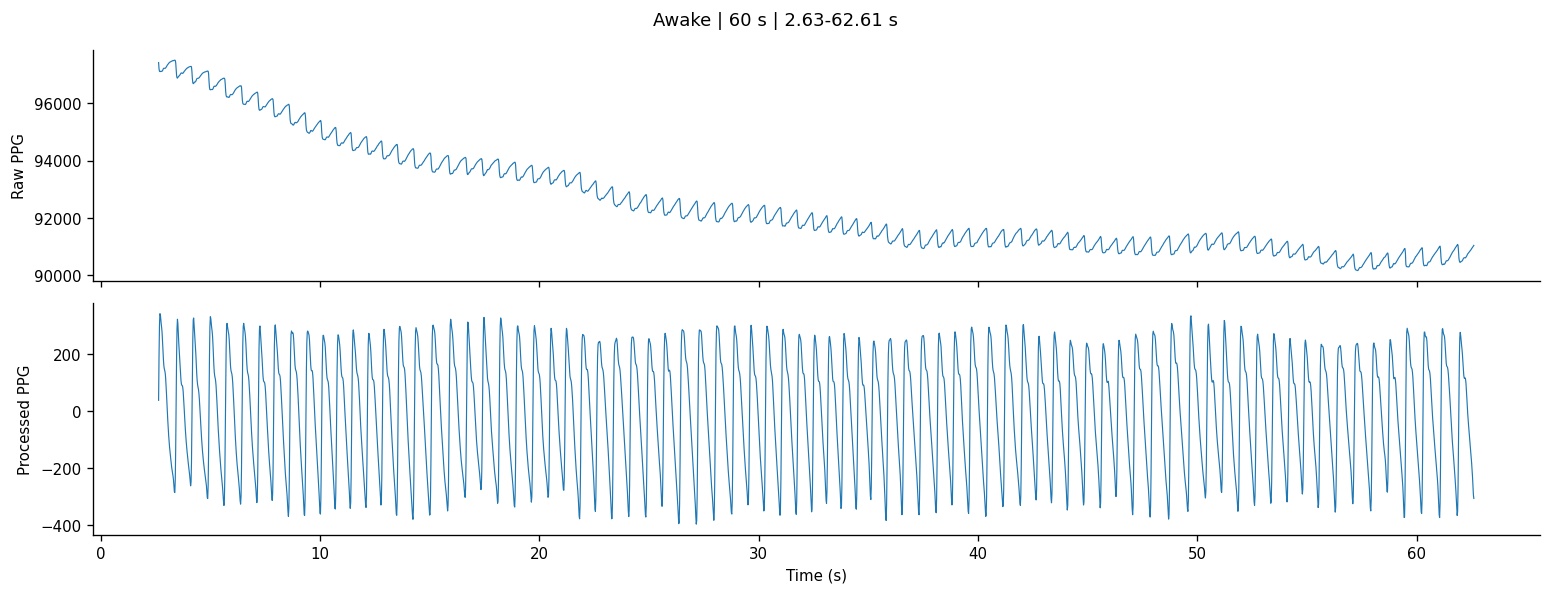

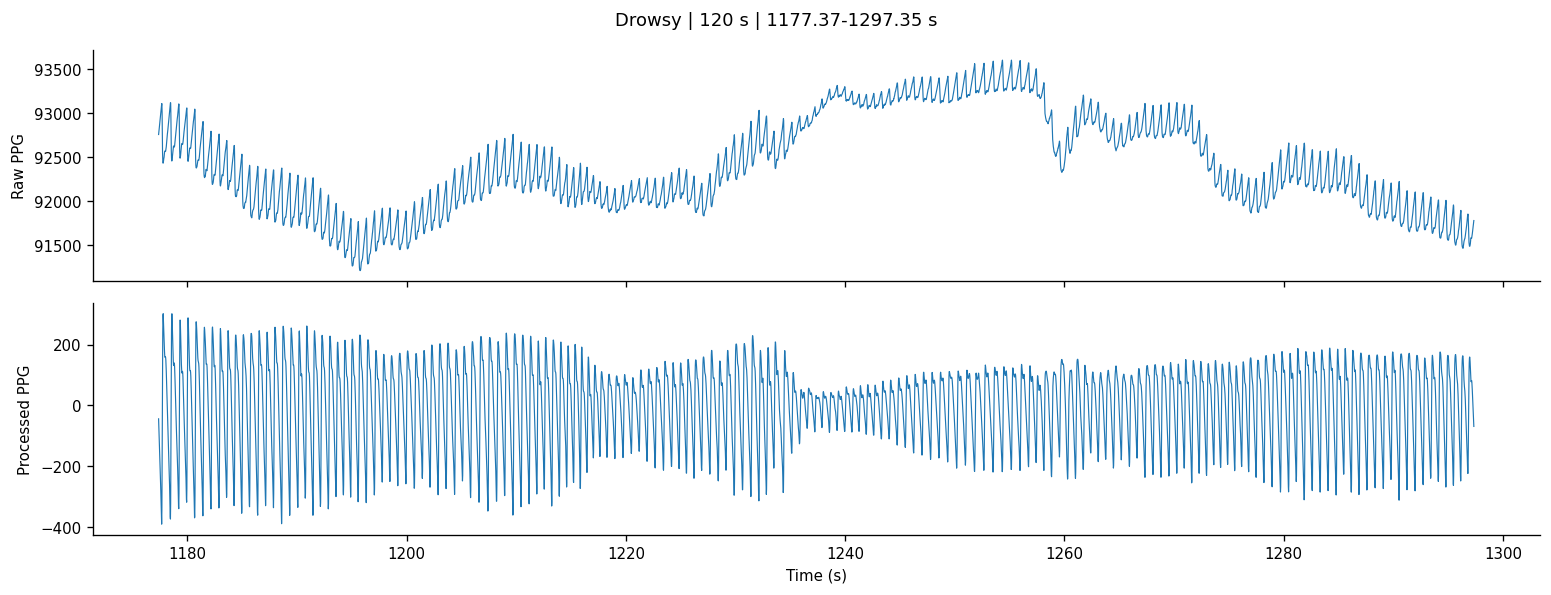

In [6]:
# Cell 6: Inspect representative Awake and Drowsy windows
def first_window(label: int, preferred_sizes: list[int]) -> dict:
    """Select the first retained window for one label."""
    for size in preferred_sizes:
        for window in segmentation_results[size]:
            if window["label"] == label:
                return window
    raise ValueError(f"No retained window found for label {label}")


awake_window = first_window(0, list(WINDOW_SIZES))
drowsy_sizes = [
    size for size in WINDOW_SIZES
    if size != awake_window["window_size_s"]
]
drowsy_sizes.append(awake_window["window_size_s"])
drowsy_window = first_window(1, drowsy_sizes)
representative_windows = [awake_window, drowsy_window]

for window in representative_windows:
    fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
    axes[0].plot(window["time"], window["ppg_raw"], linewidth=0.7)
    axes[1].plot(
        window["time"], window["ppg_processed"], linewidth=0.7
    )
    axes[0].set_ylabel("Raw PPG")
    axes[1].set_ylabel("Processed PPG")
    axes[1].set_xlabel("Time (s)")
    fig.suptitle(
        f"{LABEL_NAMES[window['label']]} | "
        f"{window['window_size_s']} s | "
        f"{window['start_time']:.2f}-{window['end_time']:.2f} s"
    )
    fig.tight_layout()
    plt.show()

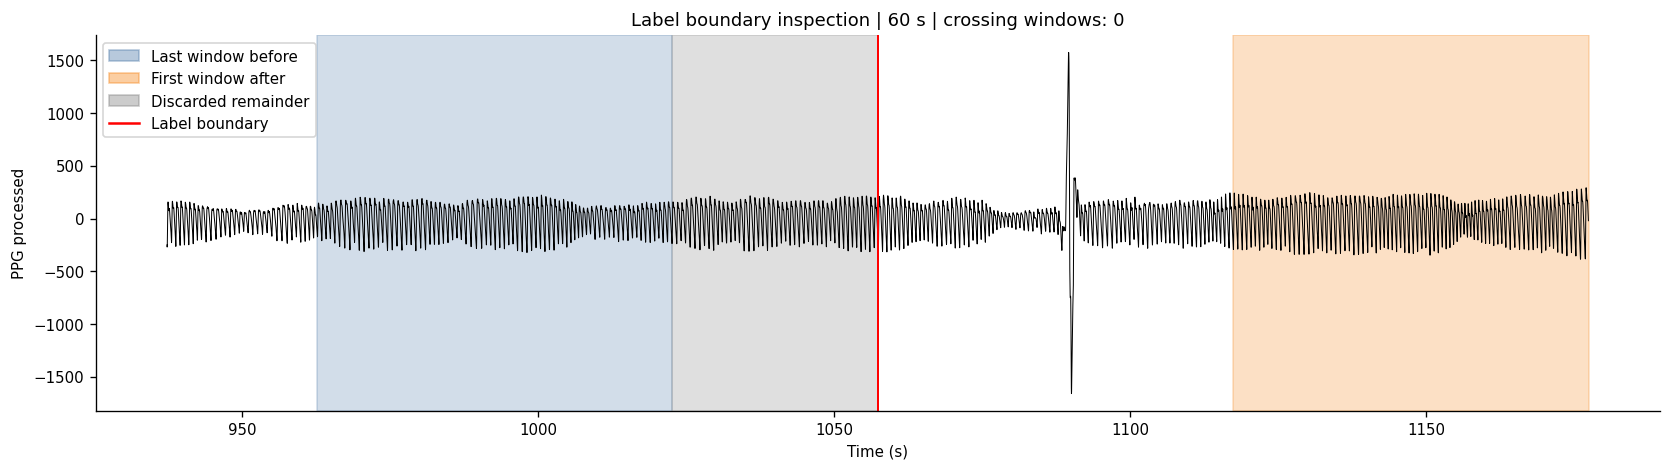

In [7]:
# Cell 7: Inspect one real label boundary
boundary_case = None
for window_s in WINDOW_SIZES:
    for previous, following in zip(label_segments[:-1], label_segments[1:]):
        boundary_index = following["start"]
        boundary_time = time_s[boundary_index]
        previous_windows = [
            window for window in segmentation_results[window_s]
            if time_s[previous["start"]] <= window["start_time"]
            and window["end_time"] < boundary_time
        ]
        following_windows = [
            window for window in segmentation_results[window_s]
            if boundary_time <= window["start_time"]
            and window["end_time"] <= time_s[following["end"] - 1]
        ]
        if previous_windows and following_windows:
            boundary_case = {
                "window_s": window_s,
                "previous": previous,
                "following": following,
                "boundary_index": boundary_index,
                "last_before": max(
                    previous_windows, key=lambda item: item["end_time"]
                ),
                "first_after": min(
                    following_windows, key=lambda item: item["start_time"]
                ),
            }
            break
    if boundary_case is not None:
        break

if boundary_case is None:
    raise AssertionError("No boundary has retained windows on both sides")

all_boundary_times = time_s[
    np.flatnonzero(labels[1:] != labels[:-1]) + 1
]
crossing_windows = [
    window
    for windows in segmentation_results.values()
    for window in windows
    if any(
        window["start_time"] < boundary <= window["end_time"]
        for boundary in all_boundary_times
    )
]
boundary_test_passed = len(crossing_windows) == 0
if not boundary_test_passed:
    raise AssertionError("A retained window crosses a label transition")

previous = boundary_case["previous"]
following = boundary_case["following"]
boundary_index = boundary_case["boundary_index"]
window_samples = int(round(boundary_case["window_s"] * fs))
previous_length = previous["end"] - previous["start"]
remainder_start = (
    previous["start"]
    + (previous_length // window_samples) * window_samples
)
plot_start = max(previous["start"], boundary_index - 2 * window_samples)
plot_end = min(following["end"], boundary_index + 2 * window_samples)

fig, axis = plt.subplots(figsize=(14, 4))
axis.plot(
    time_s[plot_start:plot_end],
    ppg_processed[plot_start:plot_end],
    color="black",
    linewidth=0.6,
)
last_before = boundary_case["last_before"]
first_after = boundary_case["first_after"]
axis.axvspan(
    last_before["start_time"],
    last_before["end_time"] + 1.0 / fs,
    color=LABEL_COLORS[last_before["label"]],
    alpha=0.25,
)
axis.axvspan(
    first_after["start_time"],
    first_after["end_time"] + 1.0 / fs,
    color=LABEL_COLORS[first_after["label"]],
    alpha=0.25,
)
if remainder_start < boundary_index:
    axis.axvspan(
        time_s[remainder_start],
        time_s[boundary_index - 1] + 1.0 / fs,
        color="0.5",
        alpha=0.25,
    )
axis.axvline(time_s[boundary_index], color="red", linewidth=1.2)
axis.set(
    title=(
        f"Label boundary inspection | {boundary_case['window_s']} s | "
        f"crossing windows: {len(crossing_windows)}"
    ),
    xlabel="Time (s)",
    ylabel="PPG processed",
)
axis.legend(handles=[
    Patch(color=LABEL_COLORS[previous["label"]], alpha=0.4,
          label="Last window before"),
    Patch(color=LABEL_COLORS[following["label"]], alpha=0.4,
          label="First window after"),
    Patch(color="0.5", alpha=0.4, label="Discarded remainder"),
    Line2D([0], [0], color="red", label="Label boundary"),
])
fig.tight_layout()
plt.show()

Window (s),Candidates overlapping SQI,Incorrectly retained
60,2,0
120,2,0
180,1,0
240,1,0
300,1,0


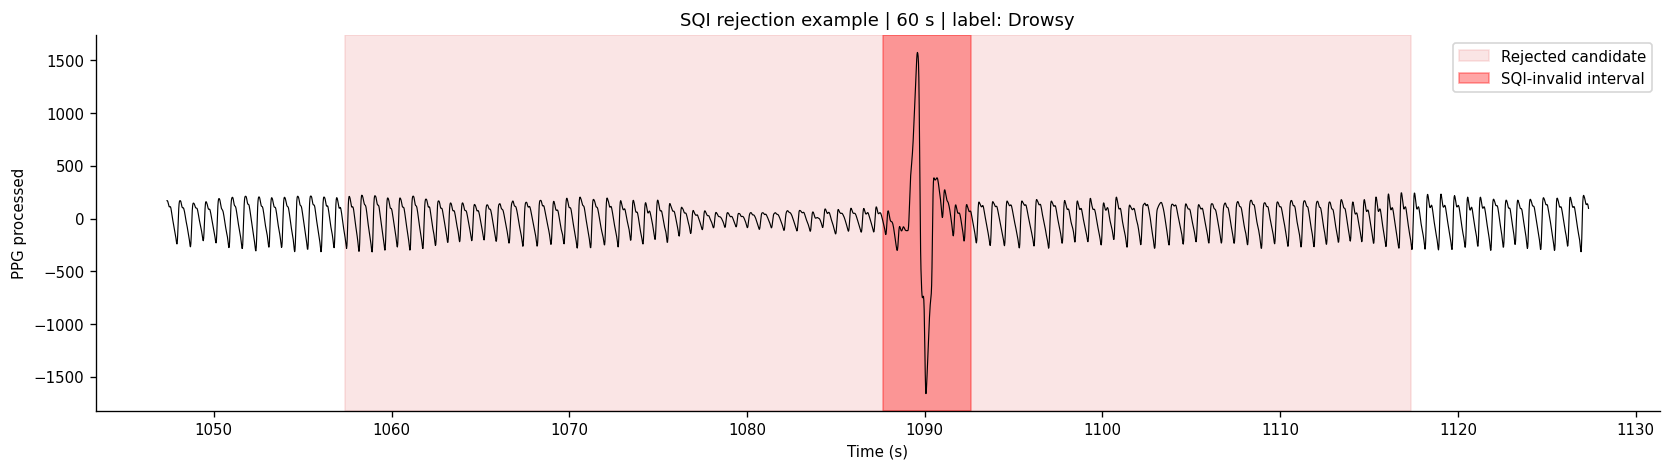

In [8]:
# Cell 8: Verify rejection of candidates that overlap SQI artifacts
retained_keys = {
    (window_s, source_indices(window, time_s)[0])
    for window_s, windows in segmentation_results.items()
    for window in windows
}
sqi_rejections = [
    candidate for candidate in candidate_windows
    if sqi_mask[candidate["start"]:candidate["end"]].any()
]
sqi_rejection_passed = all(
    (candidate["window_s"], candidate["start"]) not in retained_keys
    for candidate in sqi_rejections
)
if not sqi_rejection_passed:
    raise AssertionError("An SQI-invalid candidate was retained")

sqi_rejection_summary = pd.DataFrame({
    "Window (s)": WINDOW_SIZES,
    "Candidates overlapping SQI": [
        sum(item["window_s"] == size for item in sqi_rejections)
        for size in WINDOW_SIZES
    ],
    "Incorrectly retained": [
        sum(
            item["window_s"] == size
            and (size, item["start"]) in retained_keys
            for item in sqi_rejections
        )
        for size in WINDOW_SIZES
    ],
})
display(sqi_rejection_summary.style.hide(axis="index"))

if sqi_rejections:
    example = min(sqi_rejections, key=lambda item: item["window_s"])
    context = int(round(10 * fs))
    plot_start = max(0, example["start"] - context)
    plot_end = min(len(time_s), example["end"] + context)
    fig, axis = plt.subplots(figsize=(14, 4))
    axis.plot(
        time_s[plot_start:plot_end],
        ppg_processed[plot_start:plot_end],
        color="black",
        linewidth=0.7,
    )
    axis.axvspan(
        time_s[example["start"]],
        time_s[example["end"] - 1] + 1.0 / fs,
        color="#E45756",
        alpha=0.15,
        label="Rejected candidate",
    )
    for start, end, value in contiguous_runs(sqi_mask):
        if bool(value) and start < example["end"] and end > example["start"]:
            overlap_start = max(start, example["start"])
            overlap_end = min(end, example["end"])
            axis.axvspan(
                time_s[overlap_start],
                time_s[overlap_end - 1] + 1.0 / fs,
                color="red",
                alpha=0.35,
                label="SQI-invalid interval",
            )
    handles, legend_labels = axis.get_legend_handles_labels()
    unique = dict(zip(legend_labels, handles))
    axis.legend(unique.values(), unique.keys())
    axis.set(
        title=(
            f"SQI rejection example | {example['window_s']} s | "
            f"label: {LABEL_NAMES[example['label']]}"
        ),
        xlabel="Time (s)",
        ylabel="PPG processed",
    )
    fig.tight_layout()
    plt.show()
else:
    print("No real candidate overlaps an SQI-invalid region.")

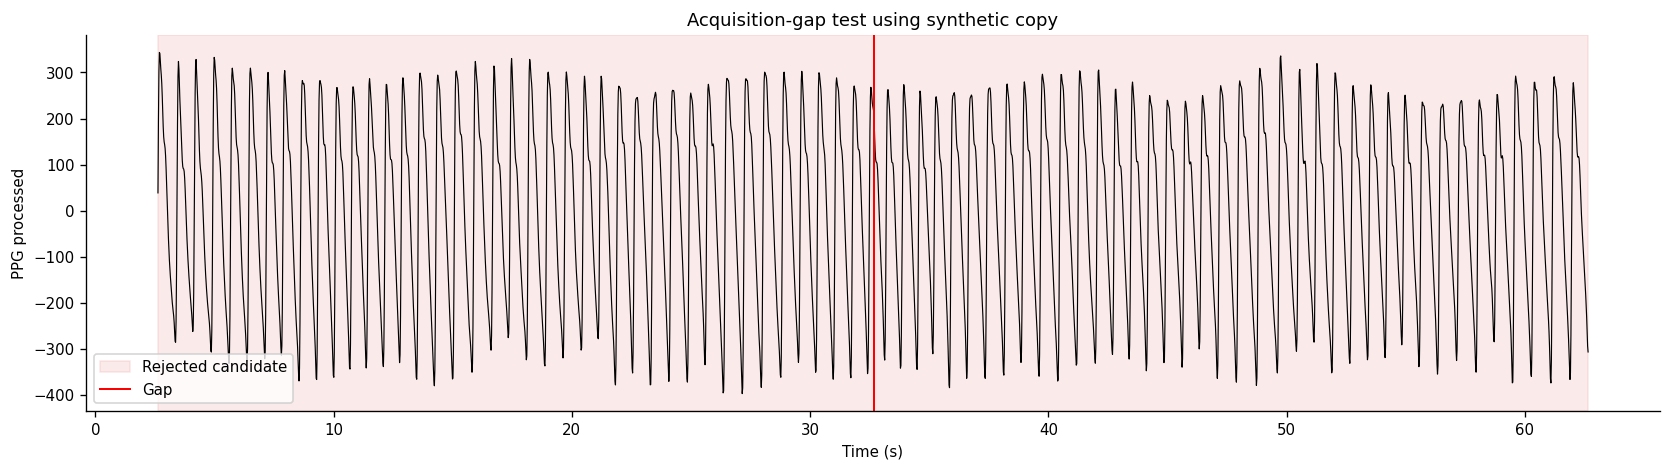

Gap rejection passed: True


In [9]:
# Cell 9: Verify rejection of acquisition gaps
def has_gap(candidate: dict, values: np.ndarray, sample_rate: float) -> bool:
    """Check whether one candidate contains an acquisition gap."""
    intervals = np.diff(values[candidate["start"]:candidate["end"]])
    return bool(np.any(intervals > GAP_FACTOR / sample_rate))


gap_rejections = [
    candidate for candidate in candidate_windows
    if has_gap(candidate, time_s, fs)
]
if gap_rejections:
    gap_test_mode = "real session"
    gap_test_passed = all(
        (item["window_s"], item["start"]) not in retained_keys
        for item in gap_rejections
    )
    example = gap_rejections[0]
    gap_time = time_s[example["start"] + 1:example["end"]][
        np.argmax(
            np.diff(time_s[example["start"]:example["end"]])
        )
    ]
    plot_time = time_s[example["start"]:example["end"]]
    plot_signal = ppg_processed[example["start"]:example["end"]]
else:
    gap_test_mode = "synthetic copy"
    clean_candidate = next(
        item for item in candidate_windows
        if not sqi_mask[item["start"]:item["end"]].any()
        and not has_gap(item, time_s, fs)
    )
    start = clean_candidate["start"]
    end = clean_candidate["end"]
    synthetic_time = time_s[start:end].copy()
    midpoint = len(synthetic_time) // 2
    synthetic_time[midpoint:] += 2.0 / fs
    synthetic_result = segment_session(
        synthetic_time,
        ppg_raw[start:end],
        ppg_processed[start:end],
        labels[start:end],
        np.zeros(end - start, dtype=bool),
        fs,
        session_id="synthetic_gap_copy",
        window_sizes=(clean_candidate["window_s"],),
        gap_factor=GAP_FACTOR,
    )
    gap_test_passed = not synthetic_result[clean_candidate["window_s"]]
    example = clean_candidate
    gap_time = synthetic_time[midpoint]
    plot_time = synthetic_time
    plot_signal = ppg_processed[start:end]

if not gap_test_passed:
    raise AssertionError("A candidate containing a gap was retained")

fig, axis = plt.subplots(figsize=(14, 4))
axis.plot(plot_time, plot_signal, color="black", linewidth=0.7)
axis.axvspan(
    plot_time[0], plot_time[-1], color="#E45756", alpha=0.12,
    label="Rejected candidate",
)
axis.axvline(gap_time, color="red", linewidth=1.2, label="Gap")
axis.set(
    title=f"Acquisition-gap test using {gap_test_mode}",
    xlabel="Time (s)",
    ylabel="PPG processed",
)
axis.legend()
fig.tight_layout()
plt.show()
print(f"Gap rejection passed: {gap_test_passed}")

In [10]:
# Cell 10: Quantify discarded remainders by label segment
remainder_rows = []
for segment in label_segments:
    segment_samples = segment["end"] - segment["start"]
    for window_s in WINDOW_SIZES:
        window_samples = int(round(window_s * fs))
        full_windows = segment_samples // window_samples
        remainder_samples = segment_samples % window_samples
        if remainder_samples >= window_samples:
            raise AssertionError("Remainder is not shorter than a window")
        remainder_rows.append({
            "Label segment": segment["segment_id"],
            "Label": LABEL_NAMES[segment["label"]],
            "Segment duration (s)": segment_samples / fs,
            "Window (s)": window_s,
            "Full windows": full_windows,
            "Remainder (s)": remainder_samples / fs,
        })

remainder_summary = pd.DataFrame(remainder_rows)
display(remainder_summary.style.format({
    "Segment duration (s)": "{:.2f}",
    "Remainder (s)": "{:.2f}",
}).hide(axis="index"))

Label segment,Label,Segment duration (s),Window (s),Full windows,Remainder (s)
1,Awake,1054.74,60,17,34.74
1,Awake,1054.74,120,8,94.74
1,Awake,1054.74,180,5,154.74
1,Awake,1054.74,240,4,94.74
1,Awake,1054.74,300,3,154.74
2,Drowsy,314.74,60,5,14.74
2,Drowsy,314.74,120,2,74.74
2,Drowsy,314.74,180,1,134.74
2,Drowsy,314.74,240,1,74.74
2,Drowsy,314.74,300,1,14.74


In [11]:
# Cell 11: Run a synthetic segmentation sanity test
synthetic_fs = 10.0
synthetic_sizes = (10, 20)
awake_samples = int(35 * synthetic_fs)
drowsy_samples = int(25 * synthetic_fs)
synthetic_count = awake_samples + drowsy_samples
synthetic_time = np.arange(synthetic_count) / synthetic_fs
synthetic_time[int(25 * synthetic_fs):] += 1.0
synthetic_raw = 1000.0 + 80.0 * np.sin(
    2.0 * np.pi * 1.2 * np.arange(synthetic_count) / synthetic_fs
)
synthetic_processed = synthetic_raw - np.mean(synthetic_raw)
synthetic_labels = np.concatenate((
    np.zeros(awake_samples, dtype=int),
    np.ones(drowsy_samples, dtype=int),
))
synthetic_sqi = np.zeros(synthetic_count, dtype=bool)
synthetic_sqi[int(12 * synthetic_fs):int(13 * synthetic_fs)] = True

synthetic_results = segment_session(
    synthetic_time,
    synthetic_raw,
    synthetic_processed,
    synthetic_labels,
    synthetic_sqi,
    synthetic_fs,
    session_id="synthetic",
    window_sizes=synthetic_sizes,
    gap_factor=GAP_FACTOR,
)
synthetic_candidates = build_candidates(
    synthetic_labels, synthetic_fs, synthetic_sizes
)
synthetic_candidate_keys = {
    (item["window_s"], item["start"]) for item in synthetic_candidates
}
synthetic_expected_keys = {
    (item["window_s"], item["start"])
    for item in synthetic_candidates
    if not synthetic_sqi[item["start"]:item["end"]].any()
    and not has_gap(item, synthetic_time, synthetic_fs)
}
synthetic_retained_keys = {
    (size, int(np.searchsorted(synthetic_time, window["start_time"])))
    for size, windows in synthetic_results.items()
    for window in windows
}
synthetic_sqi_keys = {
    (item["window_s"], item["start"])
    for item in synthetic_candidates
    if synthetic_sqi[item["start"]:item["end"]].any()
}
synthetic_gap_keys = {
    (item["window_s"], item["start"])
    for item in synthetic_candidates
    if has_gap(item, synthetic_time, synthetic_fs)
}
synthetic_no_crossing = all(
    len(np.unique(
        synthetic_labels[
            int(np.searchsorted(synthetic_time, window["start_time"])):
            int(np.searchsorted(synthetic_time, window["start_time"]))
            + len(window["time"])
        ]
    )) == 1
    for windows in synthetic_results.values()
    for window in windows
)
synthetic_checks = pd.DataFrame({
    "Check": [
        "All output keys present",
        "No retained window crosses labels",
        "SQI-overlap candidates rejected",
        "Gap-overlap candidates rejected",
        "All full clean candidates retained",
        "No padded remainder window",
    ],
    "Pass": [
        set(synthetic_results) == set(synthetic_sizes),
        synthetic_no_crossing,
        synthetic_sqi_keys.isdisjoint(synthetic_retained_keys),
        synthetic_gap_keys.isdisjoint(synthetic_retained_keys),
        synthetic_retained_keys == synthetic_expected_keys,
        synthetic_retained_keys.issubset(synthetic_candidate_keys),
    ],
})
synthetic_all_passed = bool(synthetic_checks["Pass"].all())
if not synthetic_all_passed:
    raise AssertionError("Synthetic segmentation sanity test failed")

synthetic_count_summary = pd.DataFrame({
    "Window (s)": synthetic_sizes,
    "Candidates": [
        sum(item["window_s"] == size for item in synthetic_candidates)
        for size in synthetic_sizes
    ],
    "Retained": [len(synthetic_results[size]) for size in synthetic_sizes],
})
display(synthetic_count_summary.style.hide(axis="index"))
display(synthetic_checks.style.hide(axis="index"))

Window (s),Candidates,Retained
10,5,3
20,2,1


Check,Pass
All output keys present,True
No retained window crosses labels,True
SQI-overlap candidates rejected,True
Gap-overlap candidates rejected,True
All full clean candidates retained,True
No padded remainder window,True


In [12]:
# Cell 12: Summarize segmentation validation results
final_rows = []
for window_s in WINDOW_SIZES:
    candidates = [
        item for item in candidate_windows if item["window_s"] == window_s
    ]
    sqi_failed = {
        item["start"] for item in candidates
        if sqi_mask[item["start"]:item["end"]].any()
    }
    gap_failed = {
        item["start"] for item in candidates
        if has_gap(item, time_s, fs)
    }
    retained = len(segmentation_results[window_s])
    expected_retained = len(candidates) - len(sqi_failed | gap_failed)
    if retained != expected_retained:
        raise AssertionError(
            f"Unexplained rejection count for {window_s}-second windows"
        )
    remainder_s = remainder_summary.loc[
        remainder_summary["Window (s)"] == window_s,
        "Remainder (s)",
    ].sum()
    integrity_failures = int(
        (~integrity_detail.loc[
            integrity_detail["Window (s)"] == window_s, check_names
        ]).sum().sum()
    )
    final_rows.append({
        "Window (s)": window_s,
        "Candidates": len(candidates),
        "Retained": retained,
        "Rejected by SQI": len(sqi_failed),
        "Rejected by gap": len(gap_failed),
        "Rejected by both": len(sqi_failed & gap_failed),
        "Remainder (s)": remainder_s,
        "Integrity failures": integrity_failures,
    })

final_segmentation_summary = pd.DataFrame(final_rows)
validation_checks = pd.DataFrame({
    "Validation": [
        "Five output keys and empty lists preserved",
        "All retained-window integrity checks",
        "No real window crosses a label transition",
        "Real SQI-overlap candidates rejected",
        f"Gap rejection test ({gap_test_mode})",
        "Synthetic sanity test",
    ],
    "Pass": [
        empty_key_contract,
        integrity_summary["Fail"].sum() == 0,
        boundary_test_passed,
        sqi_rejection_passed,
        gap_test_passed,
        synthetic_all_passed,
    ],
})
display(window_count_summary.style.hide(axis="index"))
display(final_segmentation_summary.style.format({
    "Remainder (s)": "{:.2f}",
}).hide(axis="index"))
display(validation_checks.style.hide(axis="index"))
print(
    "SQI and gap rejection counts are inclusive; "
    "the overlap column reports candidates failing both checks."
)
print(
    f"Validation checks passed: {int(validation_checks['Pass'].sum())} / "
    f"{len(validation_checks)}"
)

Window (s),Awake,Drowsy,Total
60,24,10,34
120,11,3,14
180,6,1,7
240,5,0,5
300,3,0,3


Window (s),Candidates,Retained,Rejected by SQI,Rejected by gap,Rejected by both,Remainder (s),Integrity failures
60,36,34,2,0,0,196.56,0
120,16,14,2,0,0,436.56,0
180,8,7,1,0,0,916.56,0
240,6,5,1,0,0,916.56,0
300,4,3,1,0,0,1156.56,0


Validation,Pass
Five output keys and empty lists preserved,True
All retained-window integrity checks,True
No real window crosses a label transition,True
Real SQI-overlap candidates rejected,True
Gap rejection test (synthetic copy),True
Synthetic sanity test,True


SQI and gap rejection counts are inclusive; the overlap column reports candidates failing both checks.
Validation checks passed: 6 / 6


## Tổng hợp kết quả kiểm thử segmentation

### Dữ liệu và cấu hình

- Session được kiểm thử: `sample_1.csv`, gồm **117.828 mẫu**, sampling rate ước lượng **50,000 Hz** và **8 contiguous label segment**.
- Dữ liệu đầu vào gồm `Time (s)`, `IR Value raw`, `PPG processed`, `Label` và mask boolean `SQI`.
- Các window size được chạy: **60, 120, 180, 240 và 300 giây**.
- Output chứa đủ 5 key và giữ list rỗng khi session không đủ độ dài cho một window size.

### Số lượng window trên dữ liệu thực

| Window (s) | Candidate | Awake | Drowsy | Retained | Reject SQI | Reject gap | Remainder (s) |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| 60 | 36 | 24 | 10 | 34 | 2 | 0 | 196,56 |
| 120 | 16 | 11 | 3 | 14 | 2 | 0 | 436,56 |
| 180 | 8 | 6 | 1 | 7 | 1 | 0 | 916,56 |
| 240 | 6 | 5 | 0 | 5 | 1 | 0 | 916,56 |
| 300 | 4 | 3 | 0 | 3 | 1 | 0 | 1.156,56 |

Tổng cộng có **70 candidate** và **63 retained window** trên năm cấu hình. Số reject do SQI trong bảng được đếm riêng theo từng window size; không có candidate dữ liệu thực nào bị reject do acquisition gap hoặc đồng thời do cả SQI và gap.

### Kiểm tra trực quan và tính toàn vẹn

- Full-session plot thể hiện Awake/Drowsy và toàn bộ label transition; timeline riêng overlay các retained window theo từng window size.
- Cell representative inspection đã chọn tự động một Awake window 60 giây và một Drowsy window 120 giây, mỗi window hiển thị đồng thời raw và processed PPG.
- Cả **63/63 retained window** đều pass từng kiểm tra: độ dài ba array bằng nhau, số mẫu đúng, chỉ có một label, không chứa `SQI=True`, không có gap và raw/processed dùng cùng interval. Không ghi nhận integrity failure.
- Label-boundary plot hiển thị window cuối trước transition, window đầu sau transition và remainder bị bỏ; số retained window vượt qua label transition là **0**.

### SQI, gap và remainder

- Số candidate overlap SQI lần lượt là **2, 2, 1, 1, 1** cho window **60, 120, 180, 240, 300 giây**; số candidate overlap SQI bị giữ nhầm là **0** ở mọi cấu hình.
- Session không có acquisition gap vượt ngưỡng `1,5 / fs`; cell gap test sử dụng synthetic copy có chèn gap và candidate tương ứng không xuất hiện trong output.
- Remainder được tính cho **8 label segment x 5 window size = 40 trường hợp**. Mỗi remainder đều ngắn hơn window tương ứng và không được pad vào output.

### Synthetic sanity test và tổng hợp validation

- Với window 10 giây: **5 candidate**, giữ **3**. Với window 20 giây: **2 candidate**, giữ **1**.
- Synthetic test ghi nhận pass cho đủ output key, không cross-label, reject SQI overlap, reject gap overlap, giữ toàn bộ full clean window và không tạo padded remainder window.
- Bảng validation cuối ghi nhận **6/6 kiểm tra pass**; toàn bộ 12 code cell chạy không có runtime error.

Nội dung trên chỉ tổng hợp các output thu được trong notebook.
